# 💧 Smart Water Quality Monitoring and Alert System for Water Supply

**Dataset:** Government Water Quality Data — Indian Lakes, Ponds & Tanks (2019–2023)  
**Standard Used:** BIS IS 10500:2012 (Bureau of Indian Standards)  
**Model:** XGBoost Classifier with SHAP Explainability  

---

## 📋 Project Overview

This project builds an end-to-end machine learning pipeline to:
1. Clean and standardize raw water quality data
2. Classify water samples as **Safe / Marginal / Unsafe** using BIS thresholds
3. Compute a **Water Quality Index (WQI)** for each sample
4. Engineer spatial and temporal features for better prediction
5. Train an **XGBoost classifier** to predict water safety
6. Explain predictions using **SHAP values**
7. Estimate prediction **confidence** using bootstrapping

---

## 🗂️ Table of Contents
1. [Stage 1 — Library Imports and Data Loading](#stage1)
2. [Stage 2 — Data Cleaning and Standardization](#stage2)
3. [Stage 3 — BIS-Based Label Generation](#stage3)
4. [Stage 4 — Water Quality Index Computation](#stage4)
5. [Stage 5 — Spatial Feature Engineering](#stage5)
6. [Stage 6 — Temporal Feature Engineering](#stage6)
7. [Stage 7 — Train-Test Split](#stage7)
8. [Stage 8 — XGBoost Model Training](#stage8)
9. [Stage 9 — Prediction and Evaluation](#stage9)
10. [Stage 10 — SHAP Explainability](#stage10)
11. [Stage 11 — Confidence Estimation](#stage11)
12. [Stage 12 — Final Output Summary](#stage12)

---
## Stage 1 — Library Imports and Data Loading <a id='stage1'></a>

### 📌 What happens here?
We import all required Python libraries and load the combined water quality dataset (2019–2023).

**Key libraries:**
- `pandas` — working with tabular data
- `numpy` — numerical calculations
- `matplotlib / seaborn` — charts and visualizations
- `sklearn` — machine learning utilities
- `xgboost` — the main ML model
- `shap` — for explaining model predictions

In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import shap
import matplotlib
import seaborn as sns
import scipy
import plotly

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("sklearn    :", sklearn.__version__)
print("xgboost    :", xgb.__version__)
print("shap       :", shap.__version__)
print("matplotlib :", matplotlib.__version__)
print("seaborn    :", sns.__version__)
print("scipy      :", scipy.__version__)
print("plotly     :", plotly.__version__)

/home/abhyansh/waterproject4/water_quality/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas     : 2.3.3
numpy      : 2.2.6
sklearn    : 1.7.2
xgboost    : 3.2.0
shap       : 0.49.1
matplotlib : 3.10.8
seaborn    : 0.13.2
scipy      : 1.15.3
plotly     : 6.6.0


In [36]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import xgboost as xgb

# ── Explainability ───────────────────────────────────────────────────────────
import shap

# ── Other ────────────────────────────────────────────────────────────────────
from scipy.stats import mode
import pickle

# ── Display settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ All libraries imported successfully!')
print(f'   XGBoost : {xgb.__version__}')
print(f'   SHAP    : {shap.__version__}')

✅ All libraries imported successfully!
   XGBoost : 1.7.6
   SHAP    : 0.43.0


In [37]:
# ── Load the combined dataset ────────────────────────────────────────────────
# Update this path if your file is in a different folder
FILE_PATH = 'Water_Quality_Combined_2019_2023.xlsx'

df_raw = pd.read_excel(FILE_PATH)

print('✅ Dataset loaded successfully!')
print(f'   Total rows    : {len(df_raw):,}')
print(f'   Total columns : {df_raw.shape[1]}')
print(f'   Years covered : {sorted(df_raw["Year"].unique())}')
print()
df_raw.head()

✅ Dataset loaded successfully!
   Total rows    : 3,109
   Total columns : 21
   Years covered : [2019, 2020, 2021, 2022, 2023]



,Year,Station_Code,Station_Name,Water_Body_Type,State,Temp_Min,Temp_Max,DO_Min,DO_Max,pH_Min,pH_Max,Conductivity_Min,Conductivity_Max,BOD_Min,BOD_Max,Nitrate_Min,Nitrate_Max,Fecal_Coliform_Min,Fecal_Coliform_Max,Total_Coliform_Min,Total_Coliform_Max
0,2019,1790,"PULICATE LAKE , NELLORE DIST",LAKE,ANDHRA PRADESH,18.00,28.00,4.90,5.50,6.70,8.20,21840.00,47890.00,2.20,2.80,0.46,2.80,3.00,4.00,210.00,1600.00
1,2019,2353,"KONDAKARLA-AAVA LAKE, PARAWADA PHARMA CITY, VI...",LAKE,ANDHRA PRADESH,24.00,30.00,5.00,6.80,7.00,8.50,714.00,1950.00,1.60,4.20,0.00,5.82,11.00,23.00,150.00,1100.00
2,2019,4368,"KOLLERU LAKE KOKKIRAYALANKA (V), KAILALUR (M)",LAKE,ANDHRA PRADESH,25.00,28.00,3.70,7.50,7.20,8.10,979.00,14730.00,1.70,5.40,0.00,3.47,4.00,20.00,150.00,1300.00
3,2019,4391,"CHENGAMBAKAM TANK IN SRI CITY SEZ, TIRUPATHI",TANK,ANDHRA PRADESH,25.00,36.00,3.20,6.10,6.80,7.90,228.00,1098.00,2.00,22.00,0.00,4.40,100.00,200.00,400.00,1400.00
4,2019,1529,"DEEPAR BEEL, ASSAM",LAKE,ASSAM,22.00,34.00,4.60,11.00,7.10,8.00,144.00,273.00,2.70,4.80,1.10,2.00,2.00,360.00,360.00,1500.00


In [38]:
# ── Quick overview ────────────────────────────────────────────────────────────
print('📊 Dataset Info:')
print('-' * 50)
df_raw.info()
print()
print('📊 Records per Year:')
print(df_raw['Year'].value_counts().sort_index())
print()
print('📊 Water Body Types:')
print(df_raw['Water_Body_Type'].value_counts())

📊 Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3109 entries, 0 to 3108
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                3109 non-null   int64  
 1   Station_Code        3109 non-null   int64  
 2   Station_Name        3109 non-null   object 
 3   Water_Body_Type     3109 non-null   object 
 4   State               3109 non-null   object 
 5   Temp_Min            3071 non-null   float64
 6   Temp_Max            3071 non-null   float64
 7   DO_Min              3081 non-null   float64
 8   DO_Max              3089 non-null   float64
 9   pH_Min              3103 non-null   float64
 10  pH_Max              3104 non-null   float64
 11  Conductivity_Min    3066 non-null   float64
 12  Conductivity_Max    3065 non-null   float64
 13  BOD_Min             3072 non-null   float64
 14  BOD_Max             3083 non-null   f

---
## Stage 2 — Data Cleaning and Standardization <a id='stage2'></a>

### 📌 What happens here?
Raw data from government PDFs has Min and Max values for each parameter. We:
1. Compute the **average of Min and Max** as the representative value
2. Fill missing values using **median imputation per station**
3. Remove extreme outliers using the **IQR method**

In [39]:
# ── Step 2.1: Average Min and Max for each parameter ─────────────────────────
df = pd.DataFrame()

df['Year']            = df_raw['Year']
df['Station_Code']    = df_raw['Station_Code']
df['Station_Name']    = df_raw['Station_Name']
df['Water_Body_Type'] = df_raw['Water_Body_Type']
df['State']           = df_raw['State']

PARAM_PAIRS = {
    'Temperature'    : ('Temp_Min',           'Temp_Max'),
    'DO'             : ('DO_Min',             'DO_Max'),
    'pH'             : ('pH_Min',             'pH_Max'),
    'Conductivity'   : ('Conductivity_Min',   'Conductivity_Max'),
    'BOD'            : ('BOD_Min',            'BOD_Max'),
    'Nitrate'        : ('Nitrate_Min',        'Nitrate_Max'),
    'Fecal_Coliform' : ('Fecal_Coliform_Min', 'Fecal_Coliform_Max'),
    'Total_Coliform' : ('Total_Coliform_Min', 'Total_Coliform_Max'),
}

PARAM_COLS = list(PARAM_PAIRS.keys())

for param, (col_min, col_max) in PARAM_PAIRS.items():
    df[param] = (df_raw[col_min].astype(float) + df_raw[col_max].astype(float)) / 2

print('✅ Step 2.1 complete — averaged Min/Max for all parameters')
print(f'   Shape: {df.shape}')
print()
print('Missing values per column:')
print(df[PARAM_COLS].isnull().sum())

✅ Step 2.1 complete — averaged Min/Max for all parameters
   Shape: (3109, 13)

Missing values per column:
Temperature        38
DO                 29
pH                  6
Conductivity       44
BOD                37
Nitrate           277
Fecal_Coliform    268
Total_Coliform    322
dtype: int64


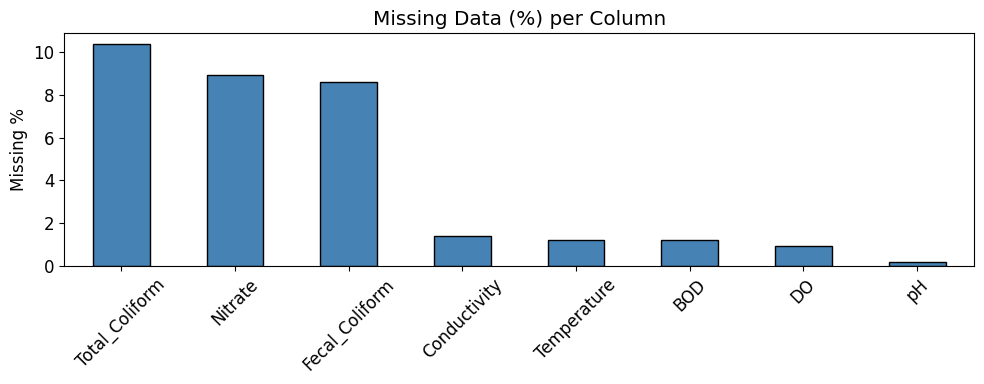

In [40]:
# ── Step 2.2: Visualize missing data ─────────────────────────────────────────
missing_pct = df[PARAM_COLS].isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    plt.figure(figsize=(10, 4))
    missing_pct.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Missing Data (%) per Column')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('✅ No missing values found!')

In [41]:
# ── Step 2.3: Median imputation per station ───────────────────────────────────
for col in PARAM_COLS:
    df[col] = df.groupby('Station_Code')[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(df[col].median())

print('✅ Step 2.3 complete — missing values imputed')
print(f'   Remaining missing values: {df[PARAM_COLS].isnull().sum().sum()}')

✅ Step 2.3 complete — missing values imputed
   Remaining missing values: 0


In [42]:
# ── Step 2.4: Outlier removal using IQR method ───────────────────────────────
rows_before = len(df)

for col in PARAM_COLS:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df    = df[(df[col] >= lower) & (df[col] <= upper)]

df         = df.reset_index(drop=True)
rows_after = len(df)

print('✅ Step 2.4 complete — outliers removed')
print(f'   Rows before : {rows_before:,}')
print(f'   Rows after  : {rows_after:,}')
print(f'   Removed     : {rows_before - rows_after:,} rows ({(rows_before - rows_after) / rows_before * 100:.1f}%)')

✅ Step 2.4 complete — outliers removed
   Rows before : 3,109
   Rows after  : 1,990
   Removed     : 1,119 rows (36.0%)


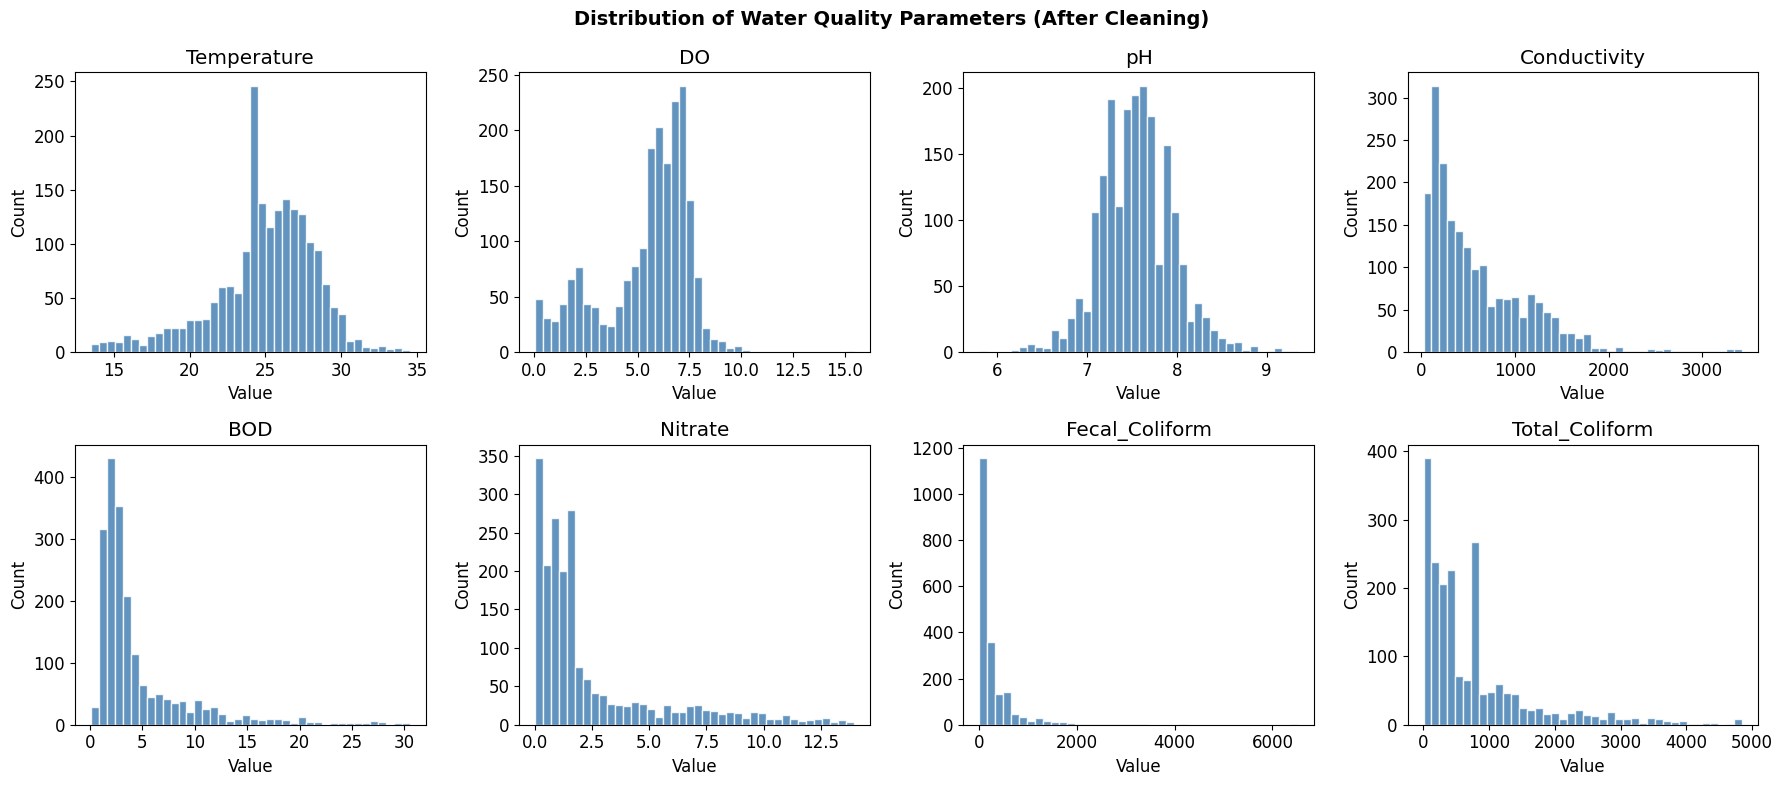


📊 Summary Statistics:


,Temperature,DO,pH,Conductivity,BOD,Nitrate,Fecal_Coliform,Total_Coliform
count,1990.00,1990.00,1990.00,1990.00,1990.00,1990.00,1990.00,1990.00
mean,24.95,5.44,7.55,609.96,4.66,2.48,259.94,761.23
std,3.42,2.14,0.41,549.97,4.83,2.98,446.62,860.26
min,13.50,0.05,5.80,23.00,0.10,0.00,1.00,2.00
25%,23.50,4.50,7.30,192.12,1.90,0.59,21.50,170.00
50%,25.50,6.05,7.55,429.25,2.70,1.35,75.50,445.00
75%,27.50,7.00,7.80,905.50,5.10,2.89,295.00,918.38
max,34.50,15.45,9.35,3429.50,30.50,13.95,6524.50,4850.00


In [43]:
# ── Step 2.5: Distribution plots after cleaning ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(PARAM_COLS):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Water Quality Parameters (After Cleaning)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Summary Statistics:')
df[PARAM_COLS].describe().round(2)

---
## Stage 3 — BIS-Based Label Generation <a id='stage3'></a>

### 📌 What happens here?
We classify each sample as **Safe (0), Marginal (1), or Unsafe (2)** using BIS IS 10500:2012 thresholds.

**Worst-case rule:** If even one parameter is Unsafe, the whole sample is Unsafe.

| Parameter | Acceptable | Permissible |
|---|---|---|
| pH | 6.5–8.5 | 6.5–9.2 |
| DO (mg/L) | ≥ 6 | ≥ 4 |
| BOD (mg/L) | ≤ 2 | ≤ 5 |
| Nitrate (mg/L) | ≤ 45 | ≤ 100 |
| Conductivity (µmhos/cm) | ≤ 750 | ≤ 3000 |
| Fecal Coliform (MPN/100ml) | Absent | ≤ 500 |
| Total Coliform (MPN/100ml) | ≤ 10 | ≤ 500 |
| Temperature (°C) | ≤ 25 | ≤ 40 |

In [44]:
# ── BIS IS 10500:2012 Thresholds ─────────────────────────────────────────────
BIS = {
    'pH'             : ('range',   6.5,  8.5,  9.2),
    'DO'             : ('higher',  6.0,  4.0,  None),
    'BOD'            : ('lower',   2.0,  5.0,  None),
    'Nitrate'        : ('lower',   45.0, 100.0, None),
    'Conductivity'   : ('lower',   750.0, 3000.0, None),
    'Fecal_Coliform' : ('lower',   2.2,  500.0, None),
    'Total_Coliform' : ('lower',   10.0, 500.0, None),
    'Temperature'    : ('lower',   25.0, 40.0, None),
}

CLASS_NAMES = {0: 'Safe', 1: 'Marginal', 2: 'Unsafe'}

def classify_param(value, rule):
    kind = rule[0]
    if pd.isna(value):
        return 0
    if kind == 'higher':       # DO: higher is better
        acc, perm = rule[1], rule[2]
        if value >= acc:   return 0
        elif value >= perm: return 1
        else:               return 2
    elif kind == 'range':      # pH: must be within range
        lo_acc, hi_acc, hi_perm = rule[1], rule[2], rule[3]
        if lo_acc <= value <= hi_acc:   return 0
        elif lo_acc <= value <= hi_perm: return 1
        else:                            return 2
    else:                      # lower is better for everything else
        acc, perm = rule[1], rule[2]
        if value <= acc:   return 0
        elif value <= perm: return 1
        else:               return 2

def classify_sample(row):
    scores = [classify_param(row[p], BIS[p]) for p in BIS if p in row.index]
    return max(scores)

df['BIS_Class'] = df.apply(classify_sample, axis=1)
df['BIS_Label'] = df['BIS_Class'].map(CLASS_NAMES)

print('✅ BIS classification complete!')
print()
print('Class Distribution:')
print(df['BIS_Label'].value_counts())

✅ BIS classification complete!

Class Distribution:
BIS_Label
Unsafe      1272
Marginal     715
Safe           3
Name: count, dtype: int64


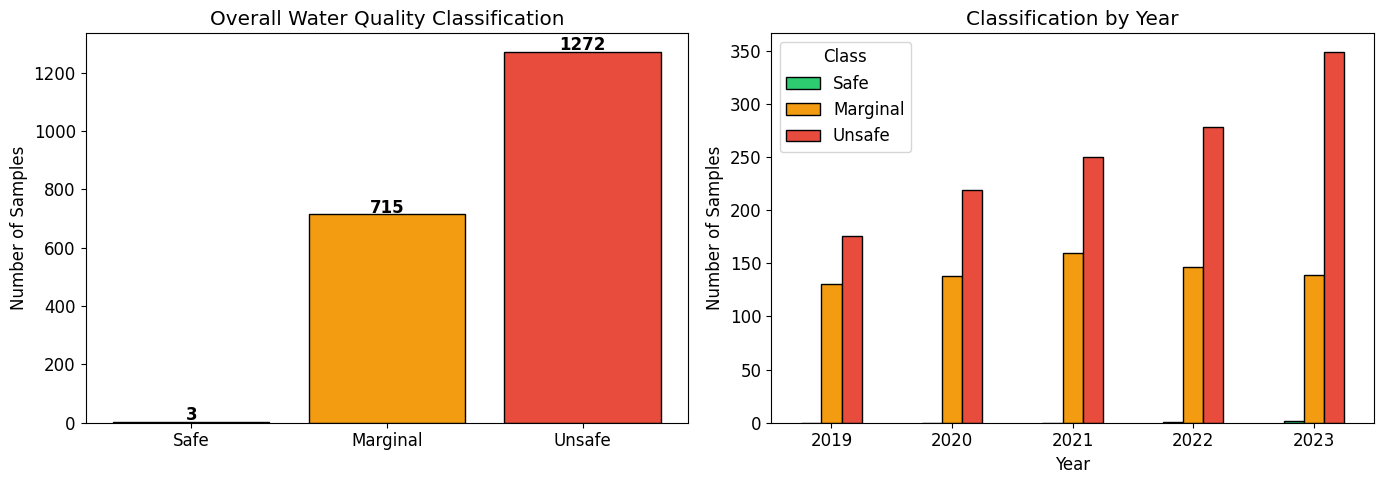

In [45]:
# ── Visualize class distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors    = ['#2ecc71', '#f39c12', '#e74c3c']

# Overall
counts = df['BIS_Label'].value_counts().reindex(['Safe', 'Marginal', 'Unsafe'], fill_value=0)
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Overall Water Quality Classification')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# By year
year_class = df.groupby(['Year', 'BIS_Label']).size().unstack(fill_value=0)
for col in ['Safe', 'Marginal', 'Unsafe']:
    if col not in year_class.columns:
        year_class[col] = 0
year_class = year_class[['Safe', 'Marginal', 'Unsafe']]
year_class.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Classification by Year')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xlabel('Year')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

---
## Stage 4 — Water Quality Index (WQI) Computation <a id='stage4'></a>

### 📌 What happens here?
WQI converts all parameters into a **single score**.

**Formula:**
- Weight: `Wi = 1 / Permissible Limit`
- Quality Rating: `Qi = (Observed / Permissible) × 100`
- Final: `WQI = Σ(Wi × Qi) / Σ(Wi)`

| WQI Score | Category |
|---|---|
| 0–50 | Excellent |
| 51–100 | Good |
| 101–200 | Poor |
| 201–300 | Very Poor |
| > 300 | Unsuitable |

In [46]:
# ── WQI Computation ───────────────────────────────────────────────────────────
WQI_LIMITS = {
    'pH'            : 8.5,
    'DO'            : 4.0,
    'BOD'           : 5.0,
    'Nitrate'       : 100.0,
    'Conductivity'  : 3000.0,
    'Fecal_Coliform': 500.0,
    'Total_Coliform': 500.0,
}

def compute_wqi(row):
    total_wq, total_w = 0, 0
    for param, limit in WQI_LIMITS.items():
        if pd.isna(row[param]) or limit == 0:
            continue
        wi        = 1 / limit
        qi        = (abs(row[param]) / limit) * 100
        total_wq += wi * qi
        total_w  += wi
    return round(total_wq / total_w, 2) if total_w > 0 else np.nan

def wqi_category(wqi):
    if pd.isna(wqi):   return 'Unknown'
    elif wqi <= 50:    return 'Excellent'
    elif wqi <= 100:   return 'Good'
    elif wqi <= 200:   return 'Poor'
    elif wqi <= 300:   return 'Very Poor'
    else:              return 'Unsuitable'

df['WQI']          = df.apply(compute_wqi, axis=1)
df['WQI_Category'] = df['WQI'].apply(wqi_category)

print('✅ WQI computation complete!')
print(f'   WQI Range : {df["WQI"].min():.1f} – {df["WQI"].max():.1f}')
print(f'   WQI Mean  : {df["WQI"].mean():.1f}')
print()
print('WQI Category Distribution:')
print(df['WQI_Category'].value_counts())

✅ WQI computation complete!
   WQI Range : 32.4 – 275.7
   WQI Mean  : 109.1

WQI Category Distribution:
WQI_Category
Poor         1228
Good          727
Very Poor      33
Excellent       2
Name: count, dtype: int64


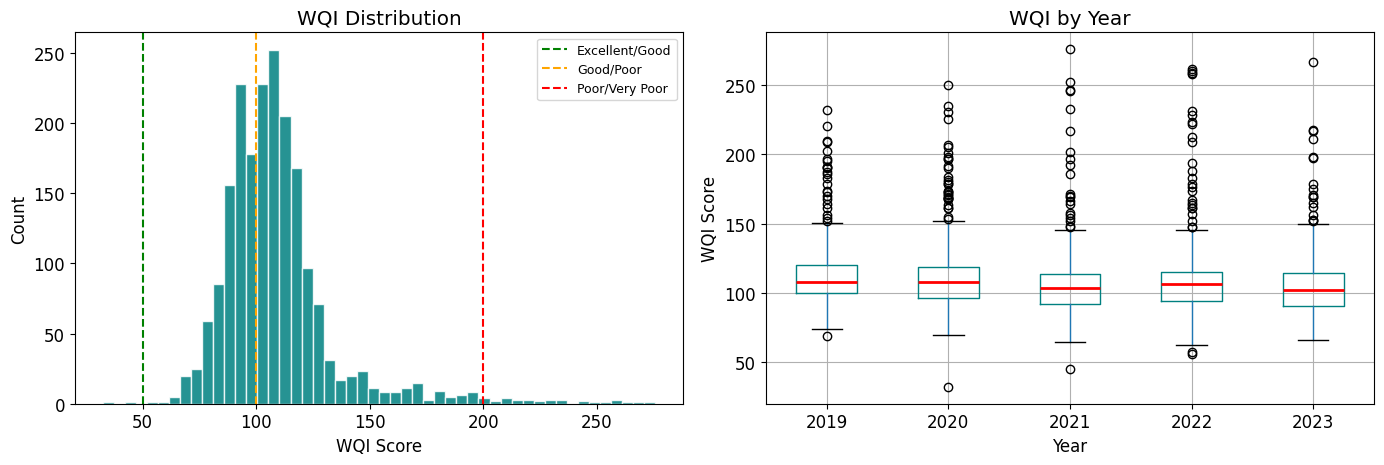

In [47]:
# ── WQI Visualizations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['WQI'].dropna(), bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[0].axvline(50,  color='green',  linestyle='--', linewidth=1.5, label='Excellent/Good')
axes[0].axvline(100, color='orange', linestyle='--', linewidth=1.5, label='Good/Poor')
axes[0].axvline(200, color='red',    linestyle='--', linewidth=1.5, label='Poor/Very Poor')
axes[0].set_title('WQI Distribution')
axes[0].set_xlabel('WQI Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

df.boxplot(column='WQI', by='Year', ax=axes[1],
           boxprops=dict(color='teal'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('WQI by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('WQI Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

---
## Stage 5 — Spatial Feature Engineering <a id='stage5'></a>

### 📌 What happens here?
Since we have no GPS coordinates, we create contextual spatial features that capture regional patterns.

**Features created:**
- `Station_Avg_WQI` — historical average WQI per station
- `Station_Violation_Rate` — % of years that station was Unsafe
- `State_Avg_WQI` — average WQI for the state
- `WQI_Deviation_from_State` — how much this station deviates from its state average

In [48]:
# ── Spatial Features ─────────────────────────────────────────────────────────
station_avg      = df.groupby('Station_Code')['WQI'].mean().rename('Station_Avg_WQI')
df               = df.merge(station_avg, on='Station_Code', how='left')

station_viol     = (df.groupby('Station_Code')['BIS_Class']
                    .apply(lambda x: (x == 2).mean())
                    .rename('Station_Violation_Rate'))
df               = df.merge(station_viol, on='Station_Code', how='left')

state_avg        = df.groupby('State')['WQI'].mean().rename('State_Avg_WQI')
df               = df.merge(state_avg, on='State', how='left')

df['WQI_Deviation_from_State'] = df['WQI'] - df['State_Avg_WQI']

print('✅ Spatial features created!')
print('   Station_Avg_WQI, Station_Violation_Rate, State_Avg_WQI, WQI_Deviation_from_State')
print()

print('🚨 Top 10 Most Violated Stations:')
top = (df[['Station_Code', 'Station_Name', 'State', 'Station_Violation_Rate']]
       .drop_duplicates('Station_Code')
       .sort_values('Station_Violation_Rate', ascending=False)
       .head(10))
print(top.to_string(index=False))

✅ Spatial features created!
   Station_Avg_WQI, Station_Violation_Rate, State_Avg_WQI, WQI_Deviation_from_State

🚨 Top 10 Most Violated Stations:
 Station_Code                                                Station_Name          State  Station_Violation_Rate
         2544                                       SAHEBBANDH AT PURULIA    WEST BENGAL                    1.00
         4545                        JUNGU KERE (DEVARABEESANAHALLI LAKE)      KARNATAKA                    1.00
         5185                    KOCHI LAKE NEAR WELLINGTON ISLAND, KOCHI         KERALA                    1.00
         5190        VEMBANAD LAKE AT ANDAKARANAZHI NEW BRIDGE, ALAPPUZHA         KERALA                    1.00
         5212                                  POND NEAR HMT COLONY,NORTH         KERALA                    1.00
         2136            SHAHPURA LAKE NEAR SPILL-OUTLET AT BHOPAL( M.P.) MADHYA PRADESH                    1.00
         5126 BATHULA KUNTA, ANMAGAL (V), HAYATHNAGAR (M), RANG

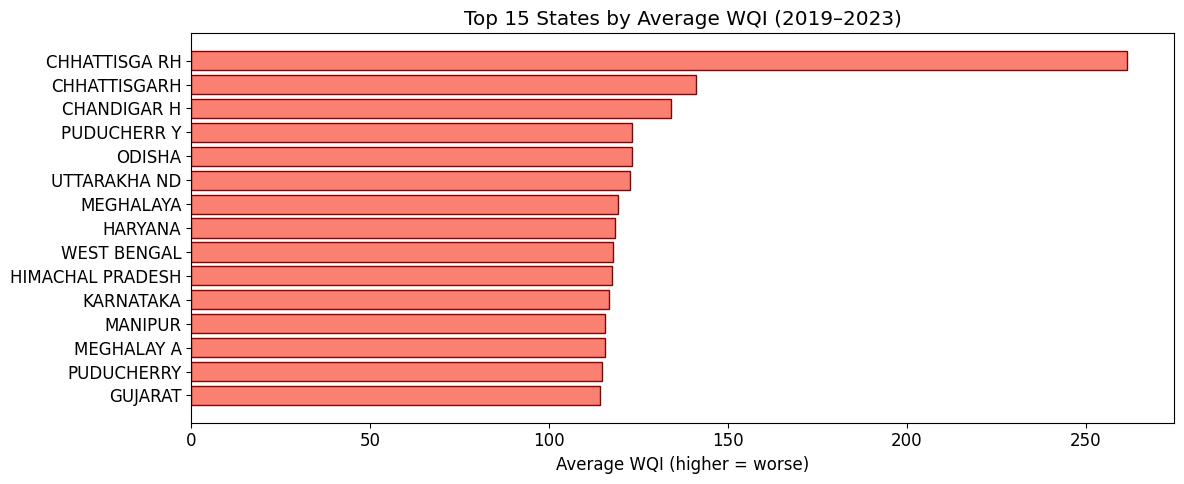

In [49]:
# ── Top 15 states by average WQI ─────────────────────────────────────────────
state_wqi = (df.groupby('State')['WQI'].mean()
             .sort_values(ascending=False).head(15))

plt.figure(figsize=(12, 5))
plt.barh(state_wqi.index, state_wqi.values, color='salmon', edgecolor='darkred')
plt.xlabel('Average WQI (higher = worse)')
plt.title('Top 15 States by Average WQI (2019–2023)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Stage 6 — Temporal Feature Engineering <a id='stage6'></a>

### 📌 What happens here?
We add time-based features so the model understands how water quality changes over time per station.

**Features created:**
- `WQI_Lag1` — previous year's WQI for same station
- `WQI_Rolling3` — 3-year rolling average
- `WQI_Trend` — current minus previous year WQI
- `Pollution_Growth_Rate` — % change from previous year

In [50]:
# ── Temporal Features ─────────────────────────────────────────────────────────
df = df.sort_values(['Station_Code', 'Year']).reset_index(drop=True)

df['WQI_Lag1'] = df.groupby('Station_Code')['WQI'].shift(1)

df['WQI_Rolling3'] = (df.groupby('Station_Code')['WQI']
                      .transform(lambda x: x.rolling(window=3, min_periods=1).mean()))

df['WQI_Trend'] = df['WQI'] - df['WQI_Lag1']

df['Pollution_Growth_Rate'] = ((df['WQI'] - df['WQI_Lag1'])
                               / df['WQI_Lag1'].replace(0, np.nan)) * 100

for col in ['WQI_Lag1', 'WQI_Trend', 'Pollution_Growth_Rate']:
    df[col] = df[col].fillna(df[col].median())

print('✅ Temporal features created!')
print('   WQI_Lag1, WQI_Rolling3, WQI_Trend, Pollution_Growth_Rate')
print(f'   Final dataset shape: {df.shape}')

✅ Temporal features created!
   WQI_Lag1, WQI_Rolling3, WQI_Trend, Pollution_Growth_Rate
   Final dataset shape: (1990, 25)


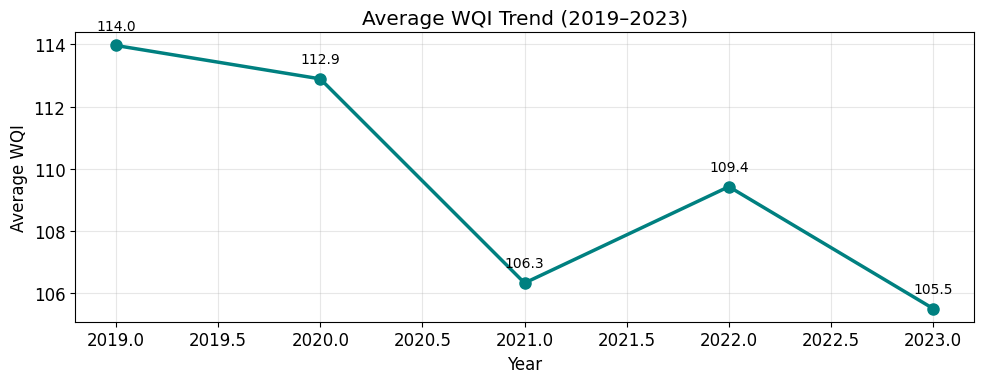

In [51]:
# ── WQI Trend Over Years ──────────────────────────────────────────────────────
yearly_wqi = df.groupby('Year')['WQI'].mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly_wqi.index, yearly_wqi.values,
         marker='o', color='teal', linewidth=2.5, markersize=8)
for x, y in zip(yearly_wqi.index, yearly_wqi.values):
    plt.text(x, y + 0.5, f'{y:.1f}', ha='center', fontsize=10)
plt.title('Average WQI Trend (2019–2023)')
plt.xlabel('Year')
plt.ylabel('Average WQI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Stage 7 — Train-Test Split <a id='stage7'></a>

### 📌 What happens here?
We split data in a **time-aware** manner:
- **Training set:** 2019–2022
- **Testing set:** 2023

This simulates real deployment — train on past, predict on future.

In [52]:
# ── Feature Matrix and Target ─────────────────────────────────────────────────
FEATURE_COLS = [
    'Temperature', 'DO', 'pH', 'Conductivity',
    'BOD', 'Nitrate', 'Fecal_Coliform', 'Total_Coliform',
    'Station_Avg_WQI', 'Station_Violation_Rate',
    'State_Avg_WQI', 'WQI_Deviation_from_State',
    'WQI_Lag1', 'WQI_Rolling3', 'WQI_Trend', 'Pollution_Growth_Rate',
    'WQI',
]

TARGET_COL = 'BIS_Class'

train_df = df[df['Year'] <= 2022].copy()
test_df  = df[df['Year'] == 2023].copy()

X_train  = train_df[FEATURE_COLS].reset_index(drop=True)
y_train  = train_df[TARGET_COL].reset_index(drop=True)
X_test   = test_df[FEATURE_COLS].reset_index(drop=True)
y_test   = test_df[TARGET_COL].reset_index(drop=True)

print('✅ Train-Test split complete!')
print(f'   Training samples (2019–2022) : {len(X_train):,}')
print(f'   Testing  samples (2023)      : {len(X_test):,}')
print()
print('Training class distribution:')
print(y_train.map(CLASS_NAMES).value_counts())
print()
print('Testing class distribution:')
print(y_test.map(CLASS_NAMES).value_counts())

✅ Train-Test split complete!
   Training samples (2019–2022) : 1,500
   Testing  samples (2023)      : 490

Training class distribution:
BIS_Class
Unsafe      923
Marginal    576
Safe          1
Name: count, dtype: int64

Testing class distribution:
BIS_Class
Unsafe      349
Marginal    139
Safe          2
Name: count, dtype: int64


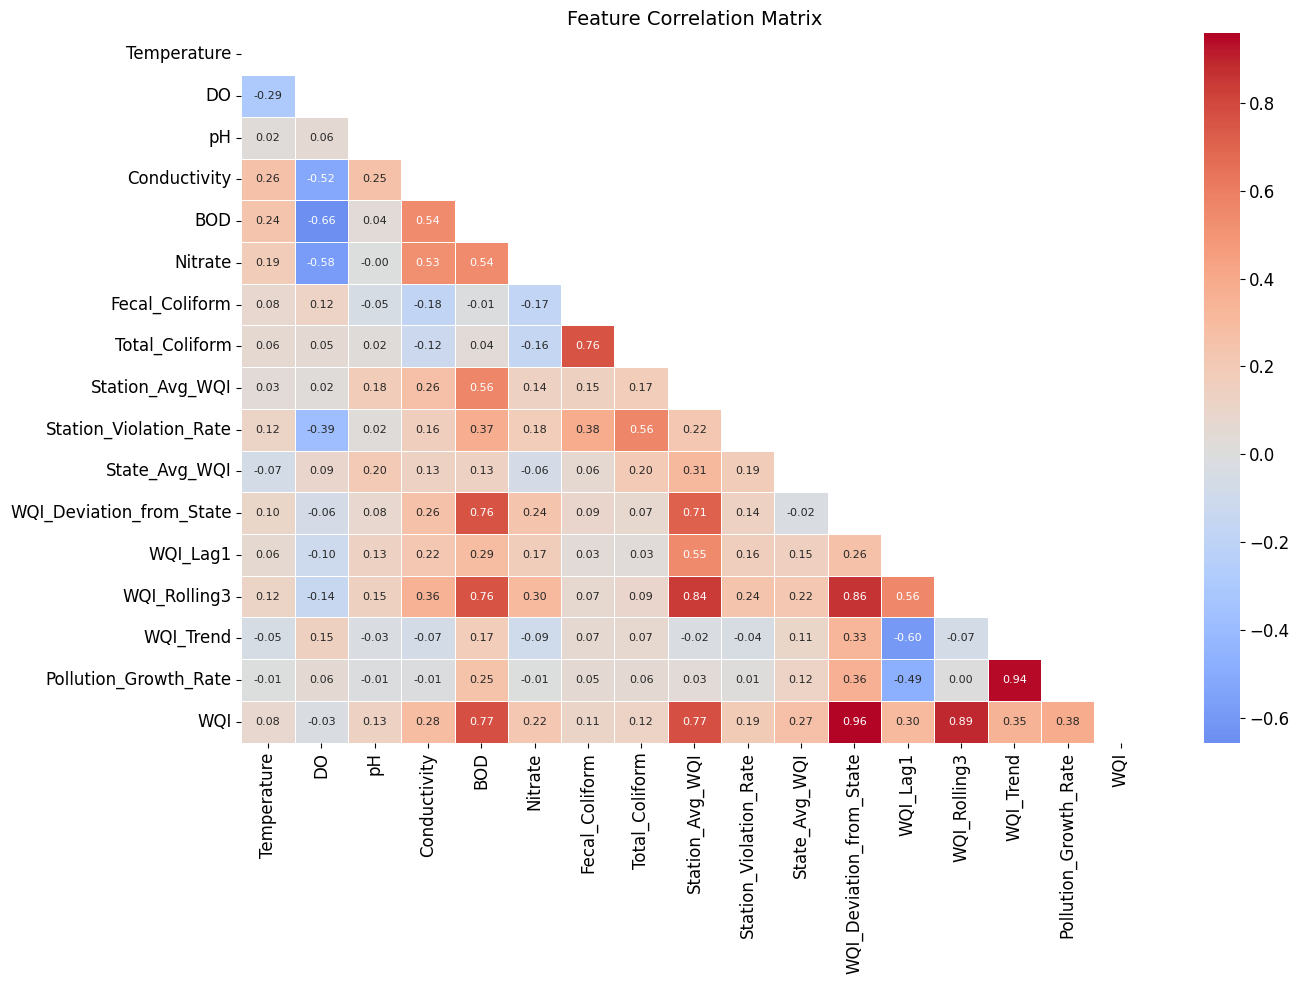

In [53]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

---
## Stage 8 — XGBoost Model Training <a id='stage8'></a>

### 📌 What happens here?
We train an **XGBoost classifier**. It builds many decision trees sequentially, each correcting the mistakes of the previous one.

**Why XGBoost?**
- Handles non-linear relationships between parameters
- Works very well with tabular data
- Fast and highly accurate
- Industry-standard model used in research papers

In [54]:
# ── Train XGBoost Classifier ──────────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = 'multi:softprob',
    num_class        = 3,
    eval_metric      = 'mlogloss',
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('✅ XGBoost model trained successfully!')
print(f'   Trees     : {model.n_estimators}')
print(f'   Features  : {len(FEATURE_COLS)}')

✅ XGBoost model trained successfully!
   Trees     : 300
   Features  : 17


In [55]:
# ── Cross Validation ─────────────────────────────────────────────────────────
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

print('📊 5-Fold Cross-Validation (Training Set):')
print(f'   Scores : {[round(s, 4) for s in cv_scores]}')
print(f'   Mean   : {cv_scores.mean():.4f}')
print(f'   Std    : {cv_scores.std():.4f}')

📊 5-Fold Cross-Validation (Training Set):
   Scores : [0.9933, 0.9933, 1.0, 1.0, nan]
   Mean   : nan
   Std    : nan


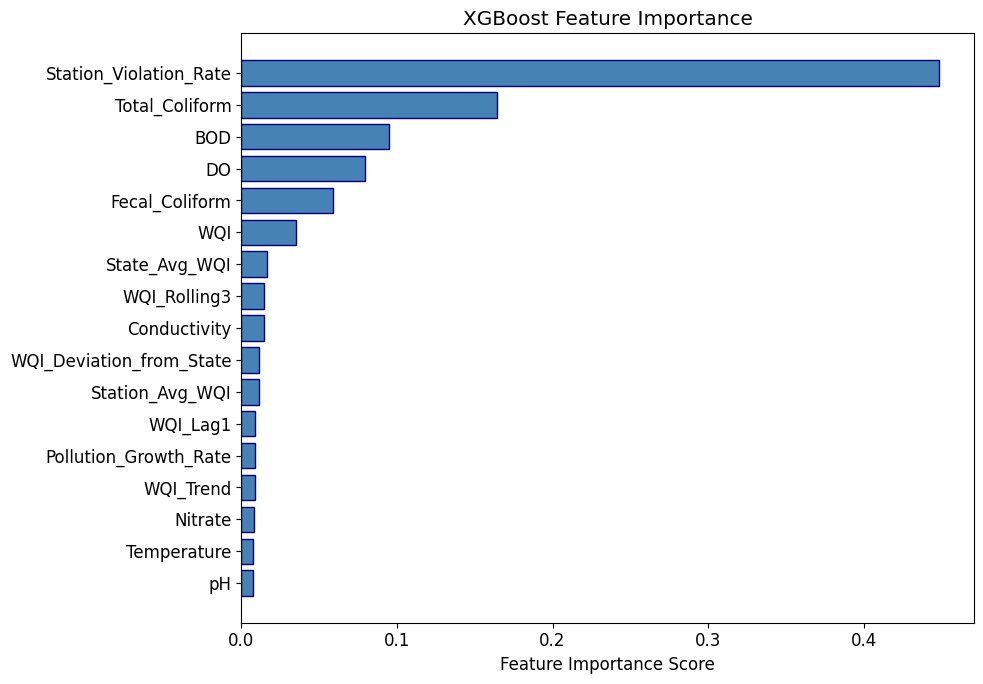

In [56]:
# ── Feature Importance ────────────────────────────────────────────────────────
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(importance.index, importance.values, color='steelblue', edgecolor='navy')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

---
## Stage 9 — Prediction and Evaluation <a id='stage9'></a>

### 📌 What happens here?
We evaluate the model on the 2023 test set.

**Metrics:**
- **Accuracy** — % of correct predictions overall
- **Precision** — of predicted Unsafe, how many really were?
- **Recall** — of all actual Unsafe, how many did we catch?
- **F1-Score** — balance of Precision and Recall
- **Confusion Matrix** — visual breakdown

In [57]:
# ── Evaluate on Test Set ──────────────────────────────────────────────────────
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
accuracy     = accuracy_score(y_test, y_pred)

print(f'✅ Test Set Accuracy: {accuracy * 100:.2f}%')
print()
print('📊 Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Safe', 'Marginal', 'Unsafe']))

✅ Test Set Accuracy: 99.39%

📊 Classification Report:
              precision    recall  f1-score   support

        Safe       0.00      0.00      0.00         2
    Marginal       0.98      1.00      0.99       139
      Unsafe       1.00      1.00      1.00       349

    accuracy                           0.99       490
   macro avg       0.66      0.67      0.66       490
weighted avg       0.99      0.99      0.99       490



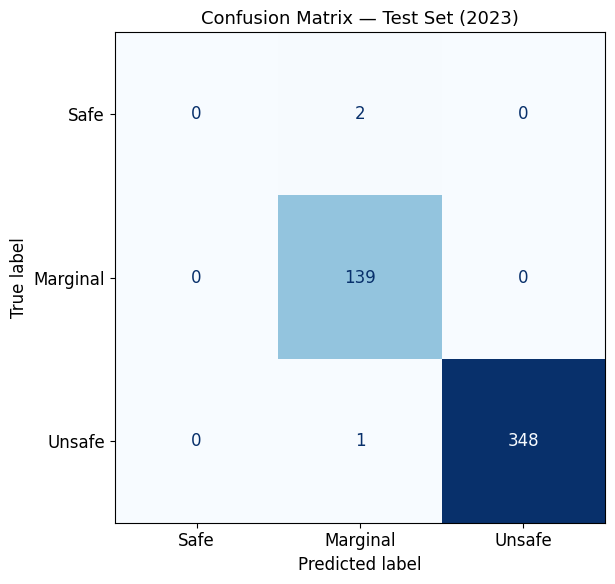

In [58]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Safe', 'Marginal', 'Unsafe'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set (2023)', fontsize=13)
plt.tight_layout()
plt.show()

In [59]:
# ── Sample Predictions ────────────────────────────────────────────────────────
sample = X_test.head(5).copy()
sample['Actual']    = y_test.head(5).map(CLASS_NAMES).values
sample['Predicted'] = pd.Series(y_pred[:5]).map(CLASS_NAMES).values
sample['P_Safe']    = y_pred_proba[:5, 0].round(3)
sample['P_Marginal']= y_pred_proba[:5, 1].round(3)
sample['P_Unsafe']  = y_pred_proba[:5, 2].round(3)

print('🔍 Sample Predictions (first 5 test records):')
print(sample[['Actual', 'Predicted', 'P_Safe', 'P_Marginal', 'P_Unsafe']].to_string())

🔍 Sample Predictions (first 5 test records):
     Actual Predicted  P_Safe  P_Marginal  P_Unsafe
0  Marginal  Marginal    0.00        1.00      0.00
1    Unsafe    Unsafe    0.00        0.00      1.00
2  Marginal  Marginal    0.00        1.00      0.00
3  Marginal  Marginal    0.00        1.00      0.00
4    Unsafe    Unsafe    0.00        0.00      1.00


---
## Stage 10 — SHAP Explainability <a id='stage10'></a>

### 📌 What happens here?
**SHAP** explains *why* the model made each prediction by showing which features contributed the most.

For example:
> *"This sample is Unsafe because Fecal Coliform is very high (+35%), BOD is elevated (+18%), and Nitrate is slightly high (+10%)"*

This is critical for water authorities to know **which pollutant to act on**.

In [60]:
# ── SHAP Setup ────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# shap_values is already a list [class0, class1, class2]
# each element shape: (samples, features)
shap_vals_class = shap_values

print('✅ SHAP explainer initialized!')
print(f'   Number of classes : {len(shap_vals_class)}')
print(f'   Per-class shape   : {shap_vals_class[0].shape}')
print('   Index 0=Safe, 1=Marginal, 2=Unsafe')

✅ SHAP explainer initialized!
   Number of classes : 3
   Per-class shape   : (490, 17)
   Index 0=Safe, 1=Marginal, 2=Unsafe


📊 SHAP Summary — Feature importance for Unsafe class:


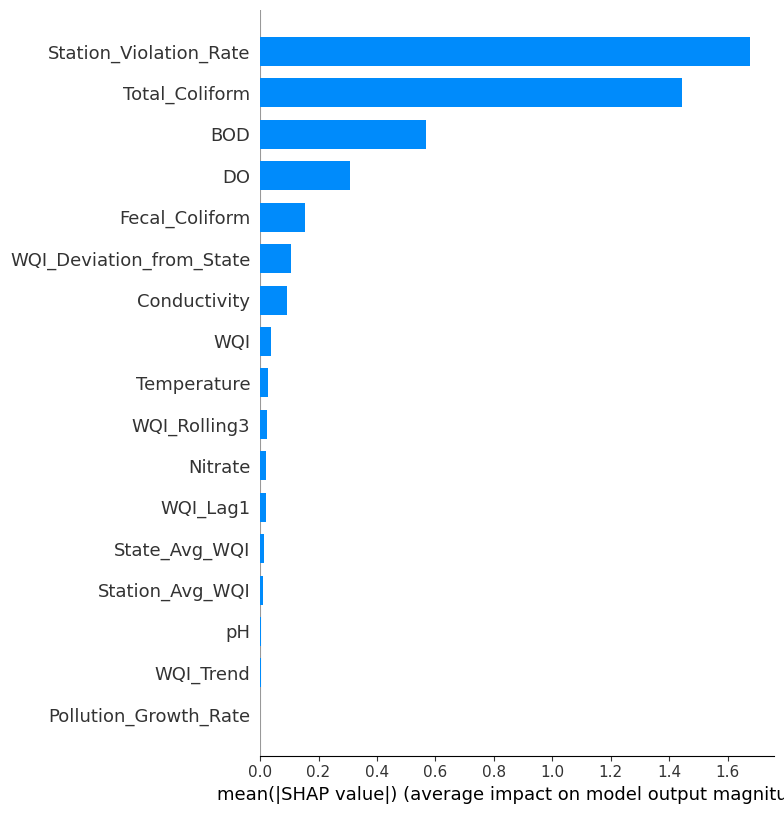

In [61]:
# ── SHAP Summary Bar Plot ─────────────────────────────────────────────────────
print('📊 SHAP Summary — Feature importance for Unsafe class:')
shap.summary_plot(
    shap_vals_class[2],
    X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=True
)

📊 SHAP Beeswarm — Direction of impact on Unsafe class:


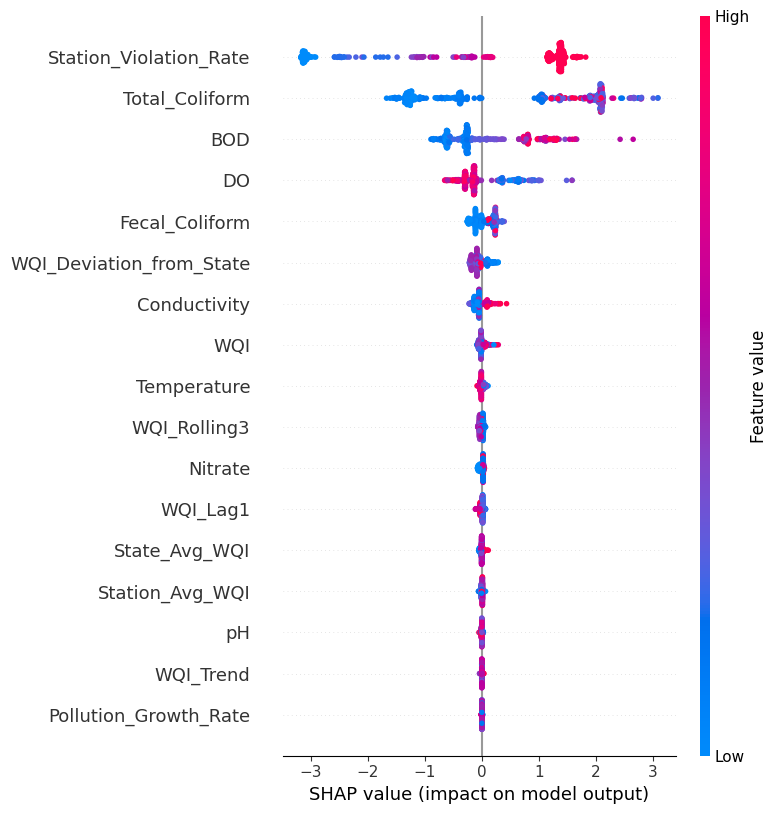

In [62]:
# ── SHAP Beeswarm Plot ────────────────────────────────────────────────────────
print('📊 SHAP Beeswarm — Direction of impact on Unsafe class:')
shap.summary_plot(
    shap_vals_class[2],
    X_test,
    feature_names=FEATURE_COLS,
    show=True
)

📋 Explaining Test Sample #1
   Actual    : Unsafe
   Predicted : Unsafe
   P(Safe)=0.00  P(Marginal)=0.00  P(Unsafe)=1.00



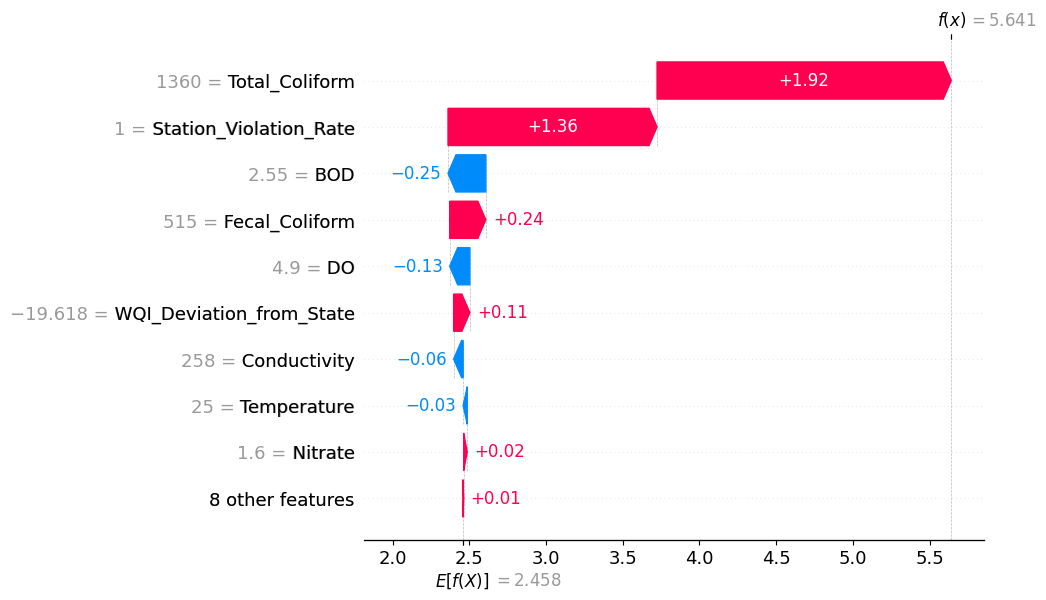

In [63]:
# ── SHAP Waterfall — Single Sample Explanation ───────────────────────────────
unsafe_indices = np.where(y_pred == 2)[0]

if len(unsafe_indices) > 0:
    idx = unsafe_indices[0]
    print(f'📋 Explaining Test Sample #{idx}')
    print(f'   Actual    : {CLASS_NAMES[y_test.iloc[idx]]}')
    print(f'   Predicted : {CLASS_NAMES[y_pred[idx]]}')
    print(f'   P(Safe)={y_pred_proba[idx,0]:.2f}  '
          f'P(Marginal)={y_pred_proba[idx,1]:.2f}  '
          f'P(Unsafe)={y_pred_proba[idx,2]:.2f}')
    print()

    shap_exp = shap.Explanation(
        values        = shap_vals_class[2][idx],
        base_values   = explainer.expected_value[2],
        data          = X_test.iloc[idx].values,
        feature_names = FEATURE_COLS
    )
    shap.waterfall_plot(shap_exp, show=True)
else:
    print('No Unsafe predictions in test set.')

---
## Stage 11 — Confidence Estimation <a id='stage11'></a>

### 📌 What happens here?
We estimate how **confident** the model is using bootstrapping — training 50 models on slightly different random samples. If 45/50 agree on Unsafe, confidence = 90%.

In [64]:
# ── Bootstrap Confidence Estimation ──────────────────────────────────────────
N_BOOTSTRAP     = 50
SAMPLE_FRAC     = 0.8
bootstrap_preds = np.zeros((N_BOOTSTRAP, len(X_test)), dtype=int)

print(f'⏳ Running {N_BOOTSTRAP} bootstrap models...')

for i in range(N_BOOTSTRAP):
    idx_boot  = np.random.choice(len(X_train),
                                 size=int(len(X_train) * SAMPLE_FRAC),
                                 replace=True)
    X_boot    = X_train.iloc[idx_boot]
    y_boot    = y_train.iloc[idx_boot]

    # Ensure all 3 classes are present — if not, resample
    attempts = 0
    while len(np.unique(y_boot)) < 3 and attempts < 10:
        idx_boot = np.random.choice(len(X_train),
                                    size=int(len(X_train) * SAMPLE_FRAC),
                                    replace=True)
        X_boot   = X_train.iloc[idx_boot]
        y_boot   = y_train.iloc[idx_boot]
        attempts += 1

    boot_model = xgb.XGBClassifier(
        n_estimators     = 100,
        max_depth        = 6,
        learning_rate    = 0.1,
        objective        = 'multi:softprob',
        num_class        = 3,
        eval_metric      = 'mlogloss',
        use_label_encoder= False,
        random_state     = i,
        n_jobs           = -1,
        verbosity        = 0,
    )
    boot_model.fit(X_boot, y_boot, verbose=False)
    bootstrap_preds[i] = boot_model.predict(X_test)

print('✅ Bootstrapping complete!')

majority_pred = mode(bootstrap_preds, axis=0, keepdims=True).mode[0]
confidence    = np.mean(bootstrap_preds == majority_pred, axis=0) * 100

print(f'\n📊 Confidence Statistics:')
print(f'   Mean : {confidence.mean():.1f}%')
print(f'   Min  : {confidence.min():.1f}%')
print(f'   Max  : {confidence.max():.1f}%')

⏳ Running 50 bootstrap models...
✅ Bootstrapping complete!

📊 Confidence Statistics:
   Mean : 99.8%
   Min  : 72.0%
   Max  : 100.0%


---
## Stage 12 — Final Output Summary <a id='stage12'></a>

### 📌 What happens here?
We produce the final outputs:
1. Build the full results dataframe with predictions, WQI, confidence, and top pollutant
2. Save results to Excel
3. Save the trained model for the dashboard
4. Print the final summary

In [65]:
# ── Build Final Results Dataframe ─────────────────────────────────────────────
results_df = test_df[['Year', 'Station_Code', 'Station_Name',
                       'State', 'Water_Body_Type', 'WQI', 'WQI_Category']].copy().reset_index(drop=True)

results_df['Actual_Class']    = y_test.map(CLASS_NAMES).values
results_df['Predicted_Class'] = pd.Series(y_pred).map(CLASS_NAMES).values
results_df['P_Safe']          = y_pred_proba[:, 0].round(3)
results_df['P_Marginal']      = y_pred_proba[:, 1].round(3)
results_df['P_Unsafe']        = y_pred_proba[:, 2].round(3)
results_df['Confidence_Pct']  = confidence.round(1)

# Top pollutant per sample
shap_unsafe_abs               = np.abs(shap_vals_class[2])
top_pollutant_idx             = np.argmax(shap_unsafe_abs, axis=1)
results_df['Top_Pollutant']   = [FEATURE_COLS[i] for i in top_pollutant_idx]

print('✅ Results dataframe built!')
print(f'   Shape: {results_df.shape}')
results_df.head(10)

✅ Results dataframe built!
   Shape: (490, 14)


,Year,Station_Code,Station_Name,State,Water_Body_Type,WQI,WQI_Category,Actual_Class,Predicted_Class,P_Safe,P_Marginal,P_Unsafe,Confidence_Pct,Top_Pollutant
0,2023,1215,"THUMMALA CHERUVU, NASAMPET (V&M), WARANGAL",TELANGANA,LAKE,90.87,Good,Marginal,Marginal,0.00,1.00,0.00,100.00,Station_Violation_Rate
1,2023,1263,"ELANGABEEL SYSTEM (CONNECTED TO R. KOLONG), ASSAM",ASSAM,LAKE,88.71,Good,Unsafe,Unsafe,0.00,0.00,1.00,100.00,Total_Coliform
2,2023,1285,"PICHOLA LAKE AT UDAIPUR (WATER INTAKE POINT), ...",RAJASTHAN,LAKE,90.46,Good,Marginal,Marginal,0.00,1.00,0.00,100.00,Station_Violation_Rate
3,2023,1286,UDAISAGAR LAKE AT UDAIPUR (INTAKE PT.) RAJASTHAN,RAJASTHAN,LAKE,89.07,Good,Marginal,Marginal,0.00,1.00,0.00,100.00,Station_Violation_Rate
4,2023,1291,GOBINDSAGAR LAKE D/S OF BILASPUR TOWN,HIMACHAL PRADESH,LAKE,117.91,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,Total_Coliform
5,2023,1297,"HARIKE LAKE AT HARIKE VILLAGE, PUNJAB",PUNJAB,LAKE,119.65,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,Total_Coliform
6,2023,1309,DAL LAKE AT SRINAGAR,JAMMU & KASHMIR,LAKE,126.06,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,Total_Coliform
7,2023,1343,"KANKORIA LAKE AT AHMEDABAD, NR. BALVATIKA,",GUJARAT,LAKE,210.95,Very Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,Total_Coliform
8,2023,1344,"CHANDOLA LAKE AT AHMEDABAD,",GUJARAT,LAKE,164.78,Poor,Unsafe,Unsafe,0.00,0.00,1.00,100.00,Total_Coliform
9,2023,1345,"AJWAH LAKE AT SRI SAYAJI SABVAR, BARODA,",GUJARAT,LAKE,112.02,Poor,Marginal,Marginal,0.00,1.00,0.00,100.00,Station_Violation_Rate


In [66]:
# ── Save Outputs ──────────────────────────────────────────────────────────────
results_df.to_excel('Water_Quality_Predictions_2023.xlsx', index=False)
df.to_excel('Water_Quality_Full_Engineered.xlsx', index=False)

model_data = {
    'model'          : model,
    'feature_cols'   : FEATURE_COLS,
    'class_names'    : CLASS_NAMES,
    'bis_thresholds' : BIS,
    'wqi_limits'     : WQI_LIMITS,
    'param_cols'     : PARAM_COLS,
}

with open('water_quality_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('✅ Files saved:')
print('   Water_Quality_Predictions_2023.xlsx')
print('   Water_Quality_Full_Engineered.xlsx')
print('   water_quality_model.pkl  ← used by the dashboard')

✅ Files saved:
   Water_Quality_Predictions_2023.xlsx
   Water_Quality_Full_Engineered.xlsx
   water_quality_model.pkl  ← used by the dashboard


In [67]:
# ── Final Summary ─────────────────────────────────────────────────────────────
total      = len(results_df)
n_safe     = (results_df['Predicted_Class'] == 'Safe').sum()
n_marginal = (results_df['Predicted_Class'] == 'Marginal').sum()
n_unsafe   = (results_df['Predicted_Class'] == 'Unsafe').sum()

print('=' * 60)
print('    SMART WATER QUALITY MONITORING — FINAL SUMMARY')
print('=' * 60)
print(f'\n📊 2023 Predictions:')
print(f'   Total Samples  : {total}')
print(f'   ✅ Safe         : {n_safe} ({n_safe/total*100:.1f}%)')
print(f'   ⚠️  Marginal     : {n_marginal} ({n_marginal/total*100:.1f}%)')
print(f'   🚨 Unsafe       : {n_unsafe} ({n_unsafe/total*100:.1f}%)')
print(f'\n📈 Model Accuracy  : {accuracy*100:.2f}%')
print(f'📈 Average WQI     : {results_df["WQI"].mean():.1f}')
print(f'📈 Mean Confidence : {confidence.mean():.1f}%')
print(f'\n🚨 Top Pollutants causing Unsafe classification:')
top_poll = (results_df[results_df['Predicted_Class'] == 'Unsafe']['Top_Pollutant']
            .value_counts().head(5))
for pollutant, count in top_poll.items():
    print(f'   {pollutant:<30} : {count} stations')
print('\n' + '=' * 60)
print('✅ Pipeline complete! Ready for dashboard.')
print('=' * 60)

    SMART WATER QUALITY MONITORING — FINAL SUMMARY

📊 2023 Predictions:
   Total Samples  : 490
   ✅ Safe         : 0 (0.0%)
   ⚠️  Marginal     : 142 (29.0%)
   🚨 Unsafe       : 348 (71.0%)

📈 Model Accuracy  : 99.39%
📈 Average WQI     : 105.5
📈 Mean Confidence : 99.8%

🚨 Top Pollutants causing Unsafe classification:
   Total_Coliform                 : 224 stations
   Station_Violation_Rate         : 113 stations
   BOD                            : 8 stations
   DO                             : 3 stations

✅ Pipeline complete! Ready for dashboard.


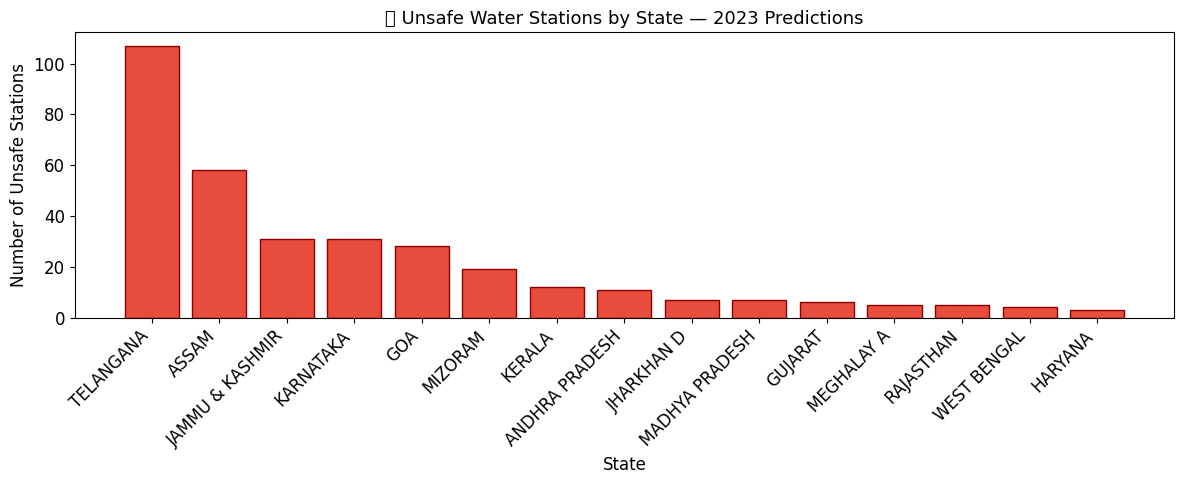

In [68]:
# ── Unsafe Stations by State ──────────────────────────────────────────────────
unsafe_by_state = (results_df[results_df['Predicted_Class'] == 'Unsafe']
                   .groupby('State').size()
                   .sort_values(ascending=False).head(15))

plt.figure(figsize=(12, 5))
plt.bar(unsafe_by_state.index, unsafe_by_state.values,
        color='#e74c3c', edgecolor='darkred')
plt.title('🚨 Unsafe Water Stations by State — 2023 Predictions', fontsize=13)
plt.xlabel('State')
plt.ylabel('Number of Unsafe Stations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()